In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# 10 sentences across exactly 3 topics: Cricket, Cooking, Cybersecurity
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker.",
    "The team celebrated after winning the cricket tournament.",
    "Fielders practiced catching drills during the evening session.",

    # Cooking (3)
    "The chef added ginger and garlic to the hot pan.",
    "She baked a chocolate cake.",
    "Fresh vegetables were chopped before making the soup.",

    # Cybersecurity (3)
    "The company installed a firewall to protect its network.",
    "Strong passwords help reduce the risk of unauthorized access.",
    "The analyst detected malware activity in the server logs."
]

In [ ]:
labels = [f"S{i+1}" for i in range(len(sentences))]
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)
sim_matrix = cosine_similarity(embeddings)
df_sim = pd.DataFrame(sim_matrix, index=labels, columns=labels)
print("10x10 Cosine Similarity Matrix:\n")
print(df_sim.round(3))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

10x10 Cosine Similarity Matrix:

        S1     S2     S3     S4     S5     S6     S7     S8     S9    S10
S1   1.000  0.343  0.547  0.219 -0.039  0.038  0.029  0.021 -0.057  0.043
S2   0.343  1.000  0.361  0.242  0.111  0.160  0.178  0.111 -0.013  0.069
S3   0.547  0.361  1.000  0.221  0.079  0.101  0.110  0.109 -0.081  0.036
S4   0.219  0.242  0.221  1.000  0.016 -0.051  0.033  0.011  0.058  0.117
S5  -0.039  0.111  0.079  0.016  1.000  0.261  0.362  0.162 -0.040  0.116
S6   0.038  0.160  0.101 -0.051  0.261  1.000  0.085  0.081 -0.068  0.049
S7   0.029  0.178  0.110  0.033  0.362  0.085  1.000  0.044 -0.133  0.064
S8   0.021  0.111  0.109  0.011  0.162  0.081  0.044  1.000  0.249  0.381
S9  -0.057 -0.013 -0.081  0.058 -0.040 -0.068 -0.133  0.249  1.000  0.108
S10  0.043  0.069  0.036  0.117  0.116  0.049  0.064  0.381  0.108  1.000


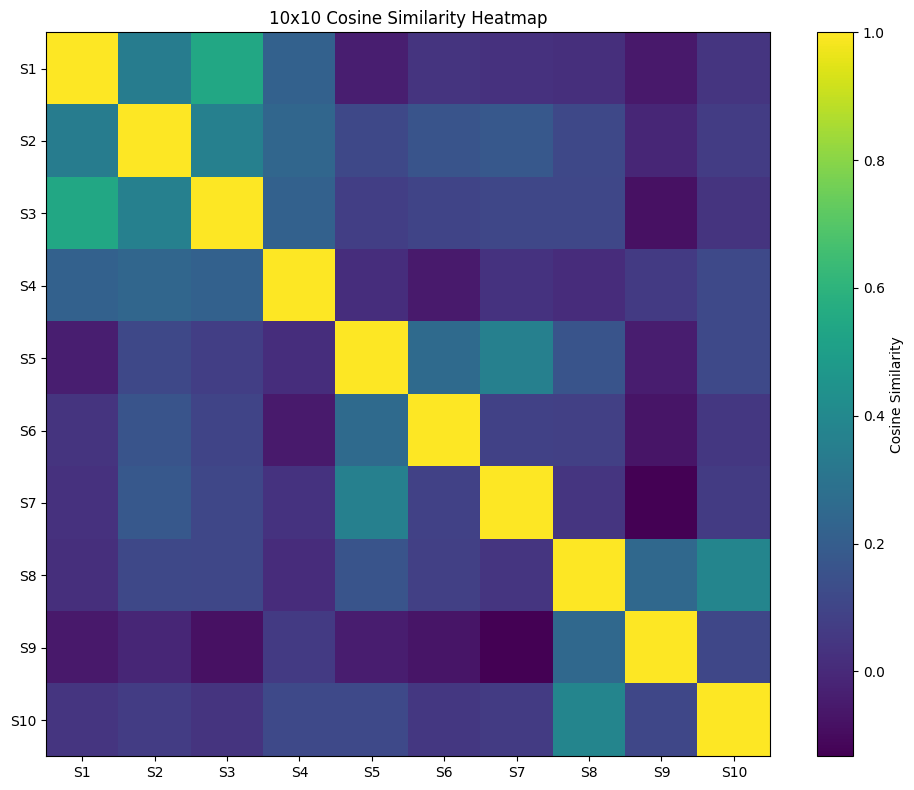

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, interpolation="nearest")
plt.colorbar(label="Cosine Similarity")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.title("10x10 Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

In [ ]:
top_2_idx = np.argsort(query_similarities)[::-1][:2]

print("\nQuery Sentence:")
print(query)

print("\nTop 2 most similar sentences:")
for idx in top_2_idx:
    print(f"- {sentences[idx]}  | Similarity Score: {query_similarities[idx]:.4f}")


Query Sentence:
The bowler took three wickets in one over

Top 2 most similar sentences:
- The batsman scored a century in the final match.  | Similarity Score: 0.5679
- The bowler delivered a fast yorker.  | Similarity Score: 0.5414
